In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import joblib

warnings.filterwarnings("ignore")

In [3]:
# Rutas
DATA_PROCESSED = Path("../data/processed/credit_clean.csv")
FIG_DIR        = Path("../reports/figures/")
MDL_DIR        = Path("../models/")

MDL_DIR.mkdir(parents=True, exist_ok=True)

# Estilos
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F8F8",
    "axes.grid":         True,
    "grid.color":        "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
    "figure.dpi":        120,
})

# Cargar dataset limpio
df = pd.read_csv(DATA_PROCESSED, index_col=0)

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 149,986 filas × 11 columnas


In [5]:
import scorecardpy as sc

TARGET = "SeriousDlqin2yrs"

# Calcular WoE e IV
bins = sc.woebin(df, y=TARGET)

# Extraer IV de cada variable manualmente
iv_list = []
for variable, tabla in bins.items():
    iv_total = tabla["bin_iv"].sum()
    iv_list.append({"variable": variable, "IV": round(iv_total, 4)})

iv_df = pd.DataFrame(iv_list).sort_values("IV", ascending=False)

print("Information Value por variable:")
print(iv_df.to_string(index=False))

[INFO] creating woe binning ...
Information Value por variable:
                            variable     IV
RevolvingUtilizationOfUnsecuredLines 1.0736
             NumberOfTimes90DaysLate 0.7889
NumberOfTime30-59DaysPastDueNotWorse 0.6896
                                 age 0.2471
     NumberOfOpenCreditLinesAndLoans 0.0754
                           DebtRatio 0.0701
                       MonthlyIncome 0.0690
        NumberRealEstateLoansOrLines 0.0553
                  NumberOfDependents 0.0338
NumberOfTime60-89DaysPastDueNotWorse 0.0000


In [6]:
FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfTimes90DaysLate",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "age",
    "MonthlyIncome",
    "DebtRatio",
]

print(f"Variables seleccionadas: {len(FEATURES)}")
for f in FEATURES:
    iv = iv_df[iv_df["variable"] == f]["IV"].values[0]
    print(f"  {f}: IV = {iv}")

Variables seleccionadas: 6
  RevolvingUtilizationOfUnsecuredLines: IV = 1.0736
  NumberOfTimes90DaysLate: IV = 0.7889
  NumberOfTime30-59DaysPastDueNotWorse: IV = 0.6896
  age: IV = 0.2471
  MonthlyIncome: IV = 0.069
  DebtRatio: IV = 0.0701


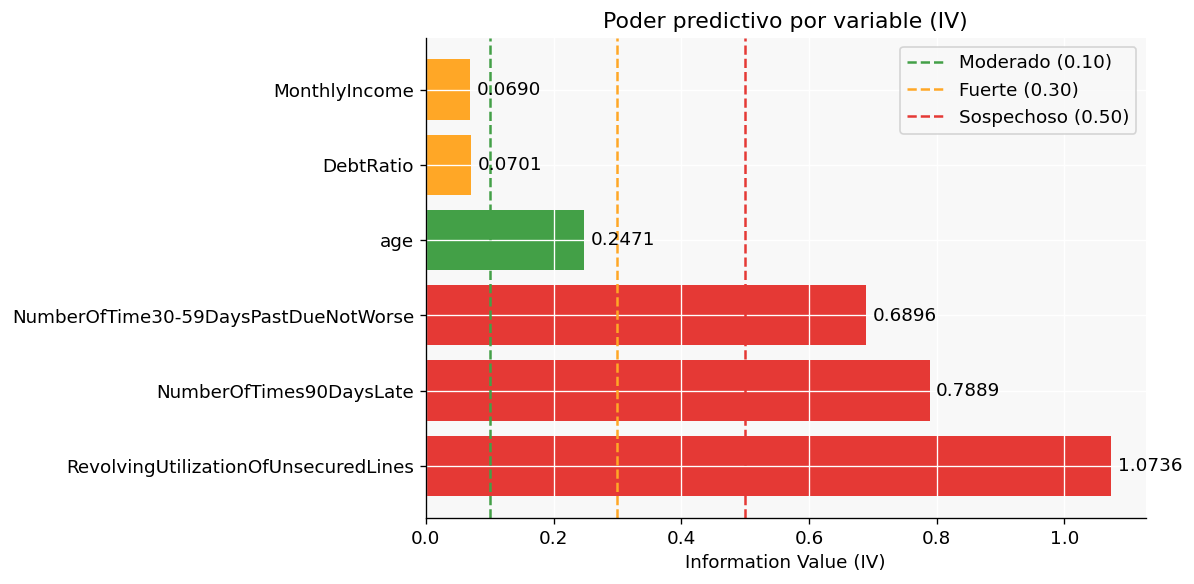

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = ["#E53935" if iv > 0.50 else 
           "#43A047" if iv > 0.10 else 
           "#FFA726" 
           for iv in iv_df[iv_df["variable"].isin(FEATURES)]["IV"]]

bars = ax.barh(
    iv_df[iv_df["variable"].isin(FEATURES)]["variable"],
    iv_df[iv_df["variable"].isin(FEATURES)]["IV"],
    color=colores
)

ax.bar_label(bars, fmt="%.4f", padding=4)
ax.axvline(0.10, color="#43A047", linestyle="--", linewidth=1.5, label="Moderado (0.10)")
ax.axvline(0.30, color="#FFA726", linestyle="--", linewidth=1.5, label="Fuerte (0.30)")
ax.axvline(0.50, color="#E53935", linestyle="--", linewidth=1.5, label="Sospechoso (0.50)")
ax.set_xlabel("Information Value (IV)")
ax.set_title("Poder predictivo por variable (IV)")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "09_iv_variables.png", bbox_inches="tight")
plt.show()

In [8]:
# Aplicar transformación WoE
df_woe = sc.woebin_ply(df[FEATURES + [TARGET]], bins)

print("Dataset transformado con WoE:")
print(df_woe.head())
print(f"\nDimensiones: {df_woe.shape}")

[INFO] converting into woe values ...
Dataset transformado con WoE:
   SeriousDlqin2yrs   age_woe  RevolvingUtilizationOfUnsecuredLines_woe  \
1                 1  0.100384                                  0.578025   
2                 0  0.449548                                  1.355483   
3                 0  0.449548                                  0.578025   
4                 0  0.449548                                 -0.406992   
5                 0  0.100384                                  1.355483   

   DebtRatio_woe  NumberOfTime30-59DaysPastDueNotWorse_woe  \
1       0.630609                                  1.864931   
2      -0.136070                                 -0.513879   
3      -0.136070                                  0.903734   
4      -0.136070                                 -0.513879   
5      -0.136070                                  0.903734   

   NumberOfTimes90DaysLate_woe  MonthlyIncome_woe  
1                    -0.368492          -0.271593  
2   

In [9]:
# Separar features y target
X = df_woe.drop(columns=[TARGET])
y = df_woe[TARGET]

# Split estratificado 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")
print(f"\nTasa default train: {y_train.mean():.2%}")
print(f"Tasa default test:  {y_test.mean():.2%}")

Train: 104,990 filas
Test:  44,996 filas

Tasa default train: 6.68%
Tasa default test:  6.69%


In [10]:
# Regresión logística
modelo = LogisticRegression(
    C=0.1,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

modelo.fit(X_train, y_train)

print("Modelo entrenado ✓")
print(f"\nCoeficientes:")
for feature, coef in zip(X_train.columns, modelo.coef_[0]):
    print(f"  {feature:<45}: {coef:.4f}")

Modelo entrenado ✓

Coeficientes:
  age_woe                                      : 0.5116
  RevolvingUtilizationOfUnsecuredLines_woe     : 0.7111
  DebtRatio_woe                                : 0.8713
  NumberOfTime30-59DaysPastDueNotWorse_woe     : 0.6882
  NumberOfTimes90DaysLate_woe                  : 0.7060
  MonthlyIncome_woe                            : 0.2314


In [11]:
# Predicciones
y_proba_train = modelo.predict_proba(X_train)[:, 1]
y_proba_test  = modelo.predict_proba(X_test)[:, 1]

# AUC-ROC
auc_train = roc_auc_score(y_train, y_proba_train)
auc_test  = roc_auc_score(y_test,  y_proba_test)

# Gini
gini_train = 2 * auc_train - 1
gini_test  = 2 * auc_test  - 1

# KS Statistic
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
ks_stat = max(tpr - fpr)

print("=" * 45)
print("METRICAS DE VALIDACION")
print("=" * 45)
print(f"AUC-ROC Train : {auc_train:.4f}")
print(f"AUC-ROC Test  : {auc_test:.4f}")
print(f"Gini Train    : {gini_train:.4f}")
print(f"Gini Test     : {gini_test:.4f}")
print(f"KS Statistic  : {ks_stat:.4f}")

METRICAS DE VALIDACION
AUC-ROC Train : 0.8455
AUC-ROC Test  : 0.8495
Gini Train    : 0.6910
Gini Test     : 0.6989
KS Statistic  : 0.5474


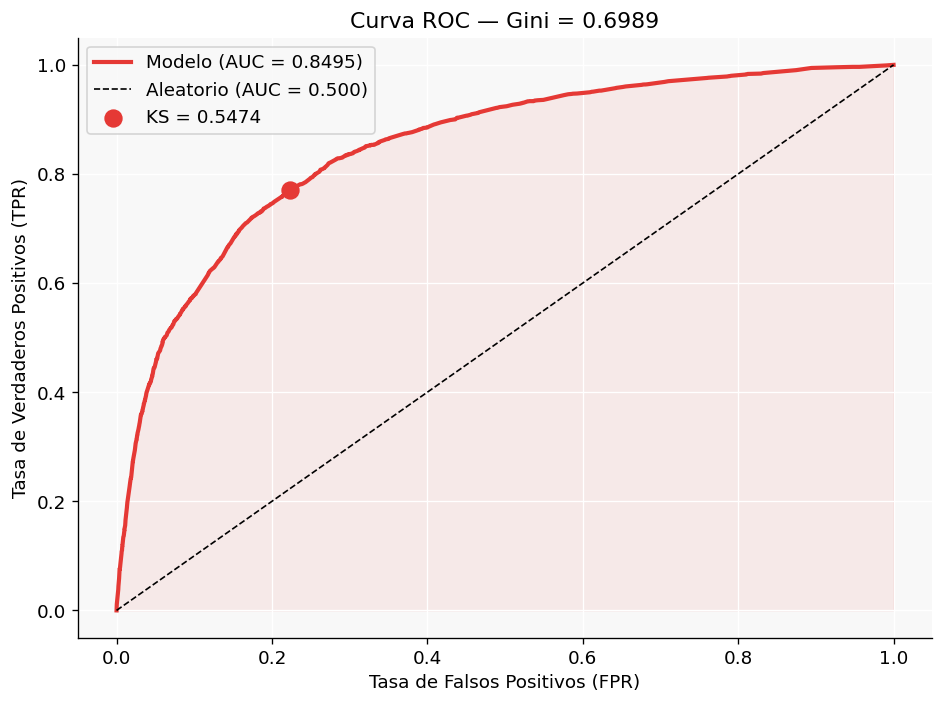

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color="#E53935", linewidth=2.5,
        label=f"Modelo (AUC = {auc_test:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, 
        label="Aleatorio (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#E53935")

# Marcar punto KS
ks_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[ks_idx], tpr[ks_idx], 
           color="#E53935", s=100, zorder=5,
           label=f"KS = {ks_stat:.4f}")

ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title(f"Curva ROC — Gini = {gini_test:.4f}")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "10_curva_roc.png", bbox_inches="tight")
plt.show()

In [13]:
# Parámetros estándar de la industria
PDO        = 20     # Points to Double Odds — cada 20 puntos se duplica el riesgo
SCORE_BASE = 600    # Score base
ODDS_BASE  = 1.0    # Odds base (probabilidad 50%)

# Factor y offset
factor = PDO / np.log(2)
offset = SCORE_BASE - factor * np.log(ODDS_BASE)

print(f"Factor : {factor:.4f}")
print(f"Offset : {offset:.4f}")

Factor : 28.8539
Offset : 600.0000


In [14]:
# Construir scorecard con scorecardpy
scorecard = sc.scorecard(
    bins,
    modelo,
    X_train.columns.tolist(),
    points0=SCORE_BASE,
    odds0=ODDS_BASE,
    pdo=PDO
)

# Ver el scorecard de una variable
print("Scorecard — NumberOfTimes90DaysLate:")
print(scorecard["NumberOfTimes90DaysLate"].to_string(index=False))

Scorecard — NumberOfTimes90DaysLate:
               variable        bin  points
NumberOfTimes90DaysLate [-inf,1.0)     8.0
NumberOfTimes90DaysLate  [1.0,inf)   -46.0


In [15]:
print("SCORECARD COMPLETO:")
print("=" * 55)
for variable, tabla in scorecard.items():
    if variable != "basepoints":
        print(f"\n{variable}:")
        print(tabla[["bin", "points"]].to_string(index=False))

SCORECARD COMPLETO:

age:
        bin  points
[-inf,44.0)    -7.0
[44.0,58.0)    -1.0
[58.0,68.0)     7.0
 [68.0,inf)    17.0

RevolvingUtilizationOfUnsecuredLines:
                       bin  points
[-inf,0.15000000000000002)    27.0
 [0.15000000000000002,0.5)     8.0
  [0.5,0.8500000000000001)   -12.0
  [0.8500000000000001,inf)   -28.0

DebtRatio:
                      bin  points
               [-inf,0.4)     3.0
               [0.4,0.55)    -3.0
[0.55,0.7000000000000001)   -10.0
 [0.7000000000000001,2.7)   -16.0
                [2.7,inf)     5.0

NumberOfTime30-59DaysPastDueNotWorse:
       bin  points
[-inf,1.0)    10.0
 [1.0,2.0)   -18.0
 [2.0,inf)   -37.0

NumberOfTimes90DaysLate:
       bin  points
[-inf,1.0)     8.0
 [1.0,inf)   -46.0

MonthlyIncome:
             bin  points
   [-inf,5000.0)    -2.0
 [5000.0,7500.0)     1.0
[7500.0,10000.0)     2.0
   [10000.0,inf)     3.0


In [17]:
# Calcular score para train y test
scores_train = sc.scorecard_ply(df.loc[X_train.index],
                                 scorecard,
                                 only_total_score=True)

scores_test  = sc.scorecard_ply(df.loc[X_test.index],
                                 scorecard,
                                 only_total_score=True)

print("Distribución de scores en test:")
print(scores_test["score"].describe().round(0))

Distribución de scores en test:
count    44996.0
mean       622.0
std         37.0
min        464.0
25%        601.0
50%        631.0
75%        650.0
max        669.0
Name: score, dtype: float64


In [18]:
# Recalibrar parámetros para mejor distribución
PDO        = 20
SCORE_BASE = 600
ODDS_BASE  = 19  # odds 19:1 = ~95% probabilidad de no default

factor = PDO / np.log(2)
offset = SCORE_BASE - factor * np.log(ODDS_BASE)

print(f"Factor : {factor:.4f}")
print(f"Offset : {offset:.4f}")

# Reconstruir scorecard con nuevos parámetros
scorecard = sc.scorecard(
    bins,
    modelo,
    X_train.columns.tolist(),
    points0=SCORE_BASE,
    odds0=ODDS_BASE,
    pdo=PDO
)

# Recalcular scores
scores_train = sc.scorecard_ply(df.loc[X_train.index],
                                 scorecard,
                                 only_total_score=True)
scores_test  = sc.scorecard_ply(df.loc[X_test.index],
                                 scorecard,
                                 only_total_score=True)

print("\nDistribución de scores en test:")
print(scores_test["score"].describe().round(0))

Factor : 28.8539
Offset : 515.0414

Distribución de scores en test:
count    44996.0
mean       707.0
std         37.0
min        549.0
25%        686.0
50%        716.0
75%        735.0
max        754.0
Name: score, dtype: float64


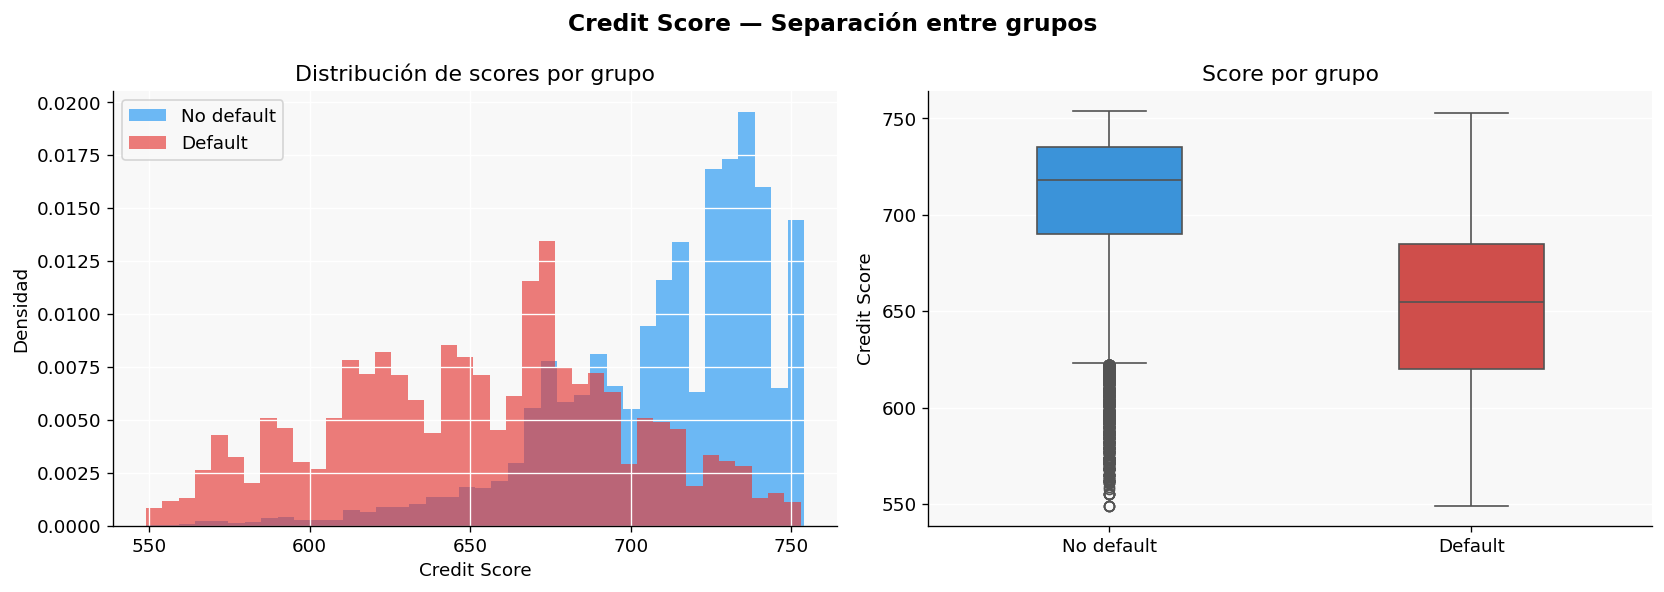

In [19]:
# Añadir scores y target al mismo DataFrame
scores_test["target"] = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma por grupo
ax = axes[0]
ax.hist(scores_test[scores_test["target"]==0]["score"],
        bins=40, alpha=0.65, color="#2196F3",
        label="No default", density=True)
ax.hist(scores_test[scores_test["target"]==1]["score"],
        bins=40, alpha=0.65, color="#E53935",
        label="Default", density=True)
ax.set_xlabel("Credit Score")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de scores por grupo")
ax.legend()

# Boxplot
ax = axes[1]
data_box = pd.DataFrame({
    "Score": scores_test["score"],
    "Grupo": scores_test["target"].map({0: "No default", 1: "Default"})
})
import seaborn as sns
sns.boxplot(data=data_box, x="Grupo", y="Score",
            palette=["#2196F3", "#E53935"],
            order=["No default", "Default"],
            width=0.4, ax=ax)
ax.set_title("Score por grupo")
ax.set_xlabel("")
ax.set_ylabel("Credit Score")

plt.suptitle("Credit Score — Separación entre grupos",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_distribucion_scores.png", bbox_inches="tight")
plt.show()

In [20]:
def clasificar_riesgo(score):
    if score >= 750:   return "1. Muy bajo"
    elif score >= 700: return "2. Bajo"
    elif score >= 650: return "3. Moderado"
    elif score >= 600: return "4. Alto"
    else:              return "5. Critico"

scores_test["riesgo"] = scores_test["score"].apply(clasificar_riesgo)

resumen = scores_test.groupby("riesgo").agg(
    total=("score", "count"),
    defaults=("target", "sum"),
    score_medio=("score", "mean"),
).assign(
    tasa_default=lambda x: x["defaults"] / x["total"] * 100,
    pct_cartera=lambda x: x["total"] / x["total"].sum() * 100,
).round(2)

print("TABLA DE RANGOS DE RIESGO:")
print("=" * 65)
print(resumen.to_string())

TABLA DE RANGOS DE RIESGO:
             total  defaults  score_medio  tasa_default  pct_cartera
riesgo                                                              
1. Muy bajo   3122        13       752.28          0.42         6.94
2. Bajo      26252       458       726.11          1.74        58.34
3. Moderado  12027      1142       679.14          9.50        26.73
4. Alto       2749       962       629.52         34.99         6.11
5. Critico     846       433       581.33         51.18         1.88


In [21]:
joblib.dump({
    "modelo":    modelo,
    "bins":      bins,
    "scorecard": scorecard,
    "features":  FEATURES,
    "metricas": {
        "auc_test":  round(auc_test, 4),
        "gini_test": round(gini_test, 4),
        "ks_stat":   round(ks_stat, 4),
    }
}, MDL_DIR / "scorecard_model.pkl")

print("Modelo guardado → models/scorecard_model.pkl ✓")

Modelo guardado → models/scorecard_model.pkl ✓


In [22]:
print("=" * 60)
print("RESUMEN EJECUTIVO — Credit Risk Scorecard (Parte 2)")
print("=" * 60)
print(f"\nModelo: Regresión Logística con transformación WoE")
print(f"Variables en modelo: {len(FEATURES)}")
print(f"\nMétricas de validación:")
print(f"  AUC-ROC  : {auc_test:.4f}")
print(f"  Gini     : {gini_test:.4f}  (benchmark > 0.35)")
print(f"  KS       : {ks_stat:.4f}  (benchmark > 0.30)")
print(f"\nScorecard (escala ajustada):")
print(f"  Score mínimo : {scores_test['score'].min():.0f}")
print(f"  Score máximo : {scores_test['score'].max():.0f}")
print(f"  Score medio  : {scores_test['score'].mean():.0f}")
print(f"\nSegmentación de cartera:")
for riesgo, row in resumen.iterrows():
    print(f"  {riesgo:<15} | "
          f"{row['pct_cartera']:5.1f}% cartera | "
          f"{row['tasa_default']:5.1f}% default")
print("=" * 60)

RESUMEN EJECUTIVO — Credit Risk Scorecard (Parte 2)

Modelo: Regresión Logística con transformación WoE
Variables en modelo: 6

Métricas de validación:
  AUC-ROC  : 0.8495
  Gini     : 0.6989  (benchmark > 0.35)
  KS       : 0.5474  (benchmark > 0.30)

Scorecard (escala ajustada):
  Score mínimo : 549
  Score máximo : 754
  Score medio  : 707

Segmentación de cartera:
  1. Muy bajo     |   6.9% cartera |   0.4% default
  2. Bajo         |  58.3% cartera |   1.7% default
  3. Moderado     |  26.7% cartera |   9.5% default
  4. Alto         |   6.1% cartera |  35.0% default
  5. Critico      |   1.9% cartera |  51.2% default
